# Pratilipi Reading Recommendation System

## Goal

The task is to recommend what a user should read next from their reading history.

I frame this as a **book recommendation** problem. The data is at chapter level, but after looking at the interaction patterns, a pure next-chapter model does not really fit the data. Most user-book pairs have only one chapter interaction, so there is not enough real progression history to confidently model “next chapter”.

The main design choice is: **do not treat all users with the same confidence**.

A user with 2 interactions should not get the same level of personalization as someone with 8+ interactions. So I first split users by how much history they have, and then change the recommendation mix by segment.

I also inspected chapter depth, but I do **not** use it in the final score. A late chapter interaction may mean the user reached that chapter, but it may also just be a one-off interaction with a late chapter. The depth signal is too weak to lean on here.

## High-level approach

I use three activity groups:

- **early_reader**: 1–3 interactions  
  Very little history. The model should not over-personalize, so it leans more on popularity and category/tag signals.

- **developing_reader**: 4–7 interactions  
  Some useful history. The model starts respecting their tags and similar-reader behavior, while still keeping popularity as a stabilizer.

- **committed_reader**: 8+ interactions  
  Enough history to trust the profile more. The model gives more weight to similar-reader signals, author affinity, genre affinity, and books that other committed readers engage with.

The final recommender combines:

- collaborative similarity,
- user tag affinity,
- author affinity,
- popularity,
- committed-reader quality,
- and a short reason for why each book was recommended.

Popularity is used as a baseline and fallback, not as the whole recommender.

## Important assumptions

The data does not include timestamps, ratings, likes, dislikes, dwell time, or completion events.

So I make a few practical assumptions:

- each interaction is treated as implicit positive feedback,
- popularity means “relatively more interacted with in this sparse catalog”, not “most users have read it”,
- a late chapter interaction is not proof of completion,
- chapter depth is useful to inspect but not reliable enough for the final score,
- evaluation uses a user-level holdout because there is no chronological order available.

This is important because the goal is not to force the fanciest recommender. The goal is to build something that fits the data we actually have.

I also made a few scope choices to keep the solution practical:

- I did not do a deep chapter-wise content/category analysis of tags. Tags are used as provided, mainly for user taste and book-category affinity. A deeper version could analyze how tags change across chapters inside a book and whether a book has a stable or mixed category identity.
- I did not use `published_date` in the final recommender. In a production version, this could be useful for separating older evergreen/classic content from recently published or newly trending books. Since the dataset does not include interaction timestamps, I avoided making claims about what is currently hot or trending.
- I use popularity as a prior/fallback, not as the full recommender. In this sparse dataset, even the most popular books are seen by a small share of users, so popularity is relative rather than universal.

In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 1. Load data

In [2]:
DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

chapters = pd.read_csv(DATA_DIR / "chapters.csv")
interactions = pd.read_csv(DATA_DIR / "interactions.csv")

print("chapters:", chapters.shape)
print("interactions:", interactions.shape)

display(chapters.head())
display(interactions.head())

chapters: (50000, 6)
interactions: (1000000, 3)


,chapter_id,chapter_sequence_no,book_id,author_id,published_date,tags
0,2812946,1,139726,66847,1990-03-22,Fantasy|Horror
1,4330764,2,139726,66847,1990-04-09,Fantasy|Young Adult|Literary Fiction
2,2664499,3,139726,66847,1990-04-07,Fantasy
3,2260666,4,139726,66847,1990-05-18,Literary Fiction|Fantasy
4,6069976,1,191772,62262,2008-07-30,Horror|Young Adult|Romance|Graphic Novel


,user_id,chapter_id,book_id
0,user_2378720,5894067,444295
1,user_2321122,2532511,785684
2,user_2335775,6777764,999595
3,user_7906001,7366896,748410
4,user_9981689,7853186,418083


In [4]:
print("Chapter columns:", chapters.columns.tolist())
print("Interaction columns:", interactions.columns.tolist())

print("\nMissing values in chapters:")
display(chapters.isna().sum())

print("\nMissing values in interactions:")
display(interactions.isna().sum())

data_summary = {
    "unique_users": interactions["user_id"].nunique(),
    "unique_books": interactions["book_id"].nunique(),
    "unique_chapters_in_interactions": interactions["chapter_id"].nunique(),
    "chapters_in_metadata": chapters["chapter_id"].nunique(),
    "unique_authors": chapters["author_id"].nunique(),
}

display(pd.Series(data_summary, name="count"))

Chapter columns: ['chapter_id', 'chapter_sequence_no', 'book_id', 'author_id', 'published_date', 'tags']
Interaction columns: ['user_id', 'chapter_id', 'book_id']

Missing values in chapters:


chapter_id             0
chapter_sequence_no    0
book_id                0
author_id              0
published_date         0
tags                   0
dtype: int64


Missing values in interactions:


user_id       0
chapter_id    0
book_id       0
dtype: int64

unique_users                       149803
unique_books                         9575
unique_chapters_in_interactions     49998
chapters_in_metadata                50000
unique_authors                       4263
Name: count, dtype: int64

## 2. User interaction frequency distribution

count    149803.000000
mean          6.675434
std           2.572317
min           1.000000
25%           5.000000
50%           6.000000
75%           8.000000
max          20.000000
Name: total_interactions, dtype: float64

,total_interactions,num_users,user_share,cumulative_user_share
0,1,1254,0.008371,0.008371
1,2,4265,0.028471,0.036842
2,3,9334,0.062308,0.099150
3,4,15808,0.105525,0.204675
4,5,20736,0.138422,0.343097
5,6,23575,0.157373,0.500471
6,7,22243,0.148482,0.648952
7,8,18322,0.122307,0.771260
8,9,13771,0.091927,0.863187
9,10,9013,0.060166,0.923353


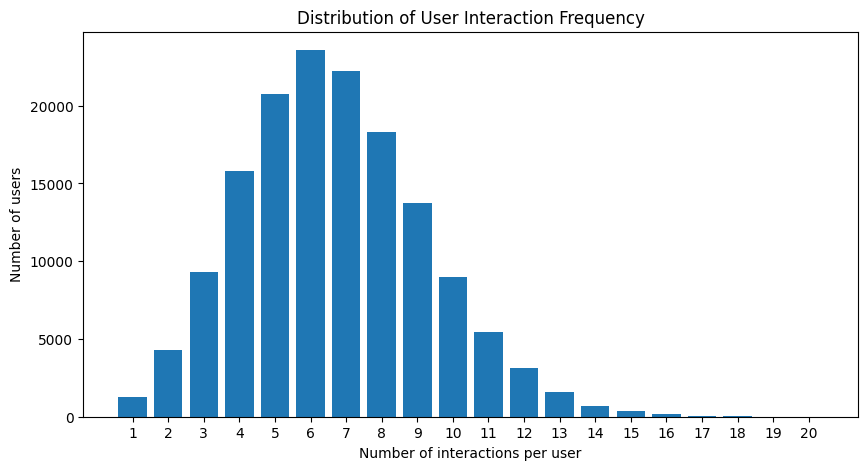

In [5]:
user_interaction_freq = (
    interactions
    .groupby("user_id")
    .size()
    .reset_index(name="total_interactions")
)

display(user_interaction_freq["total_interactions"].describe())

interaction_distribution = (
    user_interaction_freq["total_interactions"]
    .value_counts()
    .sort_index()
    .reset_index()
)

interaction_distribution.columns = ["total_interactions", "num_users"]
interaction_distribution["user_share"] = interaction_distribution["num_users"] / interaction_distribution["num_users"].sum()
interaction_distribution["cumulative_user_share"] = interaction_distribution["user_share"].cumsum()

display(interaction_distribution)

plt.figure(figsize=(10, 5))
plt.bar(interaction_distribution["total_interactions"], interaction_distribution["num_users"])
plt.xlabel("Number of interactions per user")
plt.ylabel("Number of users")
plt.title("Distribution of User Interaction Frequency")
plt.xticks(interaction_distribution["total_interactions"])
plt.show()

,activity_segment,num_users,user_share
0,early_reader,14853,0.099150
1,developing_reader,82362,0.549802
2,committed_reader,52588,0.351048


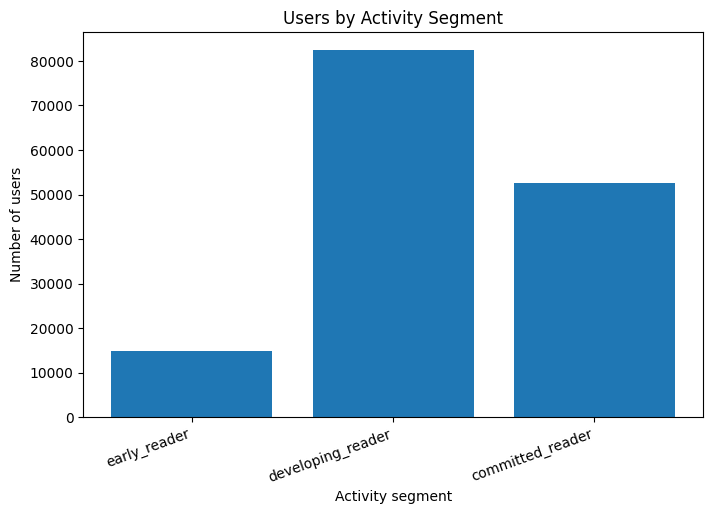

In [6]:
def assign_activity_from_count(n):
    if n <= 3:
        return "early_reader"
    if n <= 7:
        return "developing_reader"
    return "committed_reader"

user_interaction_freq["activity_segment"] = user_interaction_freq["total_interactions"].apply(assign_activity_from_count)

activity_distribution = (
    user_interaction_freq["activity_segment"]
    .value_counts()
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

activity_distribution.columns = ["activity_segment", "num_users"]
activity_distribution["user_share"] = activity_distribution["num_users"] / activity_distribution["num_users"].sum()

display(activity_distribution)

plt.figure(figsize=(8, 5))
plt.bar(activity_distribution["activity_segment"], activity_distribution["num_users"])
plt.xlabel("Activity segment")
plt.ylabel("Number of users")
plt.title("Users by Activity Segment")
plt.xticks(rotation=20, ha="right")
plt.show()

### Takeaway

This distribution is why I use activity segmentation. The median user has around 6 interactions, but the difference between 2–3 interactions and 8+ interactions matters a lot.

So frequency becomes the first-level feature:

- early readers: 1–3 interactions,
- developing readers: 4–7 interactions,
- committed readers: 8+ interactions.

Taste and similarity still matter, but only after accounting for how much user history we can actually trust.

## 3. Chapter tags and book metadata

In [7]:
chapter_tags = (
    chapters[["chapter_id", "book_id", "tags"]]
    .assign(tag=lambda df: df["tags"].astype(str).str.split("|"))
    .explode("tag")
)

chapter_tags["tag"] = chapter_tags["tag"].str.strip()

all_tags = sorted(chapter_tags["tag"].unique())
print("Unique tags:", len(all_tags))
print(all_tags)

Unique tags: 15
['Adventure', 'Crime', 'Dystopian', 'Fantasy', 'Graphic Novel', 'Historical Fiction', 'Horror', 'Humor', 'Literary Fiction', 'Mystery', 'Paranormal', 'Romance', 'Science Fiction', 'Thriller', 'Young Adult']


In [9]:
book_meta = (
    chapters
    .groupby("book_id")
    .agg(
        total_chapters=("chapter_id", "nunique"),
        author_id=("author_id", "first"),
        first_published_date=("published_date", "min")
    )
    .reset_index()
)

book_tag_profile_df = (
    chapter_tags
    .groupby(["book_id", "tag"])
    .size()
    .reset_index(name="tag_count")
)

book_tag_profile_df["total_tag_count"] = book_tag_profile_df.groupby("book_id")["tag_count"].transform("sum")
book_tag_profile_df["book_tag_score"] = book_tag_profile_df["tag_count"] / book_tag_profile_df["total_tag_count"]

dominant_book_tag = (
    book_tag_profile_df
    .sort_values(["book_id", "book_tag_score"], ascending=[True, False])
    .drop_duplicates("book_id")
    [["book_id", "tag", "book_tag_score"]]
    .rename(columns={"tag": "dominant_tag", "book_tag_score": "dominant_tag_share"})
)

book_meta = book_meta.merge(dominant_book_tag, on="book_id", how="left")

display(book_meta.head())
display(book_meta["total_chapters"].describe())

,book_id,total_chapters,author_id,first_published_date,dominant_tag,dominant_tag_share
0,100089,3,55121,1995-03-24,Fantasy,0.750000
1,100096,1,61876,2015-12-31,Romance,1.000000
2,100193,4,67983,1996-01-26,Thriller,0.307692
3,100205,4,64099,2016-02-26,Adventure,0.363636
4,100301,3,77538,2015-08-14,Humor,0.600000


count    9575.000000
mean        5.221932
std         4.056853
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        20.000000
Name: total_chapters, dtype: float64

## 4. User-book interaction table

In [10]:
interactions_with_chapters = interactions.merge(
    chapters[["chapter_id", "book_id", "chapter_sequence_no", "author_id"]],
    on=["chapter_id", "book_id"],
    how="left"
).merge(
    book_meta[["book_id", "total_chapters"]],
    on="book_id",
    how="left"
)

interactions_with_chapters["chapter_depth_ratio"] = (
    interactions_with_chapters["chapter_sequence_no"] / interactions_with_chapters["total_chapters"]
)

user_book = (
    interactions_with_chapters
    .groupby(["user_id", "book_id"])
    .agg(
        interaction_count=("chapter_id", "size"),
        distinct_chapters=("chapter_id", "nunique"),
        max_chapter_sequence=("chapter_sequence_no", "max"),
        min_chapter_sequence=("chapter_sequence_no", "min"),
        avg_chapter_depth=("chapter_depth_ratio", "mean"),
        max_chapter_depth=("chapter_depth_ratio", "max"),
        author_id=("author_id", "first"),
        total_chapters=("total_chapters", "first")
    )
    .reset_index()
)

user_book["coverage_ratio"] = user_book["distinct_chapters"] / user_book["total_chapters"]

# Final model uses interaction frequency as implicit feedback.
# Chapter depth is kept for EDA, but not used in scoring.
user_book["engagement_weight"] = np.log1p(user_book["interaction_count"])

display(user_book.head())
display(user_book[[
    "interaction_count",
    "distinct_chapters",
    "avg_chapter_depth",
    "max_chapter_depth",
    "coverage_ratio",
    "engagement_weight"
]].describe())

,user_id,book_id,interaction_count,distinct_chapters,max_chapter_sequence,min_chapter_sequence,avg_chapter_depth,max_chapter_depth,author_id,total_chapters,coverage_ratio,engagement_weight
0,user_0000013,200976,1,1,5,5,0.625000,0.625000,97819,8,0.125000,0.693147
1,user_0000013,461083,1,1,1,1,0.125000,0.125000,34356,8,0.125000,0.693147
2,user_0000013,469844,1,1,2,2,1.000000,1.000000,52899,2,0.500000,0.693147
3,user_0000013,635456,1,1,7,7,0.875000,0.875000,46822,8,0.125000,0.693147
4,user_0000013,878246,1,1,1,1,0.111111,0.111111,22675,9,0.111111,0.693147


,interaction_count,distinct_chapters,avg_chapter_depth,max_chapter_depth,coverage_ratio,engagement_weight
count,999520.000000,999520.000000,999520.000000,999520.000000,999520.000000,999520.000000
mean,1.000480,1.000480,0.595739,0.595830,0.192802,0.693342
std,0.021909,0.021909,0.288454,0.288478,0.161164,0.008883
min,1.000000,1.000000,0.050000,0.050000,0.050000,0.693147
25%,1.000000,1.000000,0.333333,0.333333,0.083333,0.693147
50%,1.000000,1.000000,0.600000,0.600000,0.142857,0.693147
75%,1.000000,1.000000,0.833333,0.833333,0.250000,0.693147
max,2.000000,2.000000,1.000000,1.000000,1.000000,1.098612


## 5. Check how much chapter progression signal exists

In [11]:
progression_summary = {
    "total_interactions": len(interactions),
    "unique_user_book_pairs": len(user_book),
    "pairs_with_multiple_interactions": int((user_book["interaction_count"] > 1).sum()),
    "pairs_with_multiple_distinct_chapters": int((user_book["distinct_chapters"] > 1).sum()),
    "share_pairs_multiple_interactions": float((user_book["interaction_count"] > 1).mean()),
    "share_pairs_multiple_distinct_chapters": float((user_book["distinct_chapters"] > 1).mean()),
}

display(pd.Series(progression_summary))
display(user_book["interaction_count"].value_counts().head(10).rename("user_book_pair_count").to_frame())

total_interactions                        1000000.00000
unique_user_book_pairs                     999520.00000
pairs_with_multiple_interactions              480.00000
pairs_with_multiple_distinct_chapters         480.00000
share_pairs_multiple_interactions               0.00048
share_pairs_multiple_distinct_chapters          0.00048
dtype: float64

,user_book_pair_count
interaction_count,
1,999040
2,480


### Takeaway

Repeated user-book progression is almost absent. Only a tiny fraction of user-book pairs have more than one chapter interaction.

So I do not build a pure next-chapter recommender. I keep the recommendation task at book level and use chapter/order fields only for exploratory checks.

## 6. Train/test split

In [12]:
eligible_users = (
    user_book
    .groupby("user_id")["book_id"]
    .nunique()
    .reset_index(name="books_read")
)

eligible_users = eligible_users[eligible_users["books_read"] >= 3]["user_id"]
eval_user_book = user_book[user_book["user_id"].isin(eligible_users)].copy()

test_rows = []
for user_id, group in eval_user_book.groupby("user_id"):
    test_rows.append(rng.choice(group.index.to_numpy(), size=1)[0])

test_idx = set(test_rows)

test_user_book = eval_user_book.loc[list(test_idx)].copy()
train_user_book = eval_user_book.drop(index=list(test_idx)).copy()

print("Eligible users:", eval_user_book["user_id"].nunique())
print("Train rows:", train_user_book.shape)
print("Test rows:", test_user_book.shape)
print("Unique test users:", test_user_book["user_id"].nunique())

Eligible users: 144273
Train rows: (845442, 12)
Test rows: (144273, 12)
Unique test users: 144273


From here onward, user features are built from the **training split only**. This avoids using the held-out book while profiling users.

## 7. Train-only user activity segments

In [13]:
train_user_activity = (
    train_user_book
    .groupby("user_id")
    .agg(
        train_total_interactions=("interaction_count", "sum"),
        train_books_read=("book_id", "nunique"),
        train_total_engagement=("engagement_weight", "sum"),
        avg_depth=("max_chapter_depth", "mean"),
        median_depth=("max_chapter_depth", "median"),
        late_depth_book_count=("max_chapter_depth", lambda x: int((x >= 0.75).sum())),
        max_depth=("max_chapter_depth", "max")
    )
    .reset_index()
)

def assign_activity_segment(row):
    if row["train_total_interactions"] <= 3:
        return "early_reader"
    if row["train_total_interactions"] <= 7:
        return "developing_reader"
    return "committed_reader"

train_user_activity["activity_segment"] = train_user_activity.apply(assign_activity_segment, axis=1)

activity_segment_counts = (
    train_user_activity["activity_segment"]
    .value_counts()
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

activity_segment_counts.columns = ["activity_segment", "users"]
activity_segment_counts["share"] = activity_segment_counts["users"] / activity_segment_counts["users"].sum()

display(activity_segment_counts)
display(train_user_activity.head())

,activity_segment,users,share
0,early_reader,25138,0.174239
1,developing_reader,84875,0.588294
2,committed_reader,34260,0.237466


,user_id,train_total_interactions,train_books_read,train_total_engagement,avg_depth,median_depth,late_depth_book_count,max_depth,activity_segment
0,user_0000013,6,6,4.158883,0.534858,0.549020,3,1.000000,developing_reader
1,user_0000115,5,5,3.465736,0.552222,0.600000,1,0.800000,developing_reader
2,user_0000177,5,5,3.465736,0.461558,0.500000,0,0.636364,developing_reader
3,user_0000188,7,7,4.852030,0.569161,0.500000,2,1.000000,developing_reader
4,user_0000257,4,4,2.772589,0.630952,0.595238,2,1.000000,developing_reader


## 8. Tag/category mix by user activity segment

In [14]:
train_pairs = train_user_book[["user_id", "book_id"]].copy()
train_pairs["is_train"] = 1

train_interactions = interactions.merge(train_pairs, on=["user_id", "book_id"], how="inner")

train_interaction_tags = train_interactions.merge(
    chapter_tags[["chapter_id", "book_id", "tag"]],
    on=["chapter_id", "book_id"],
    how="left"
)

train_interaction_tags = train_interaction_tags.merge(
    train_user_activity[["user_id", "activity_segment"]],
    on="user_id",
    how="left"
)

segment_tag_mix = (
    train_interaction_tags
    .groupby(["activity_segment", "tag"])
    .size()
    .reset_index(name="tag_interactions")
)

segment_tag_mix["segment_total"] = segment_tag_mix.groupby("activity_segment")["tag_interactions"].transform("sum")
segment_tag_mix["tag_share_within_segment"] = segment_tag_mix["tag_interactions"] / segment_tag_mix["segment_total"]

display(
    segment_tag_mix
    .sort_values(["activity_segment", "tag_share_within_segment"], ascending=[True, False])
    .groupby("activity_segment")
    .head(8)
)

,activity_segment,tag,tag_interactions,segment_total,tag_share_within_segment
14,committed_reader,Young Adult,54724,794452,0.068883
1,committed_reader,Crime,54036,794452,0.068017
5,committed_reader,Historical Fiction,53772,794452,0.067684
13,committed_reader,Thriller,53717,794452,0.067615
2,committed_reader,Dystopian,53606,794452,0.067475
11,committed_reader,Romance,53289,794452,0.067076
4,committed_reader,Graphic Novel,53285,794452,0.067071
6,committed_reader,Horror,53076,794452,0.066808
29,developing_reader,Young Adult,80355,1160448,0.069245
16,developing_reader,Crime,78868,1160448,0.067963


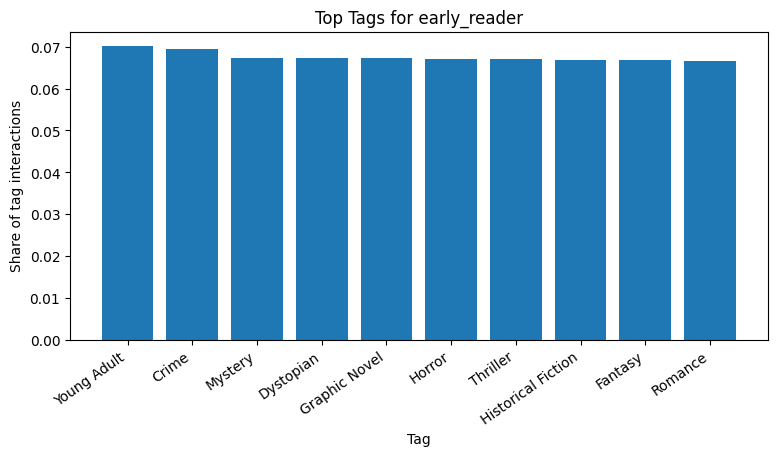

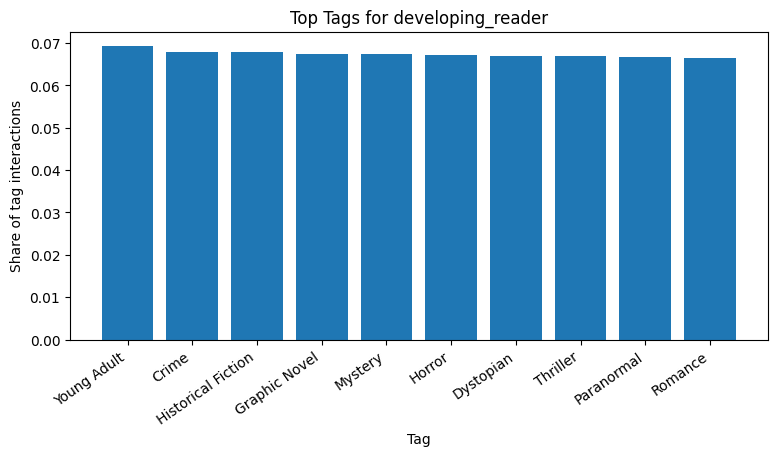

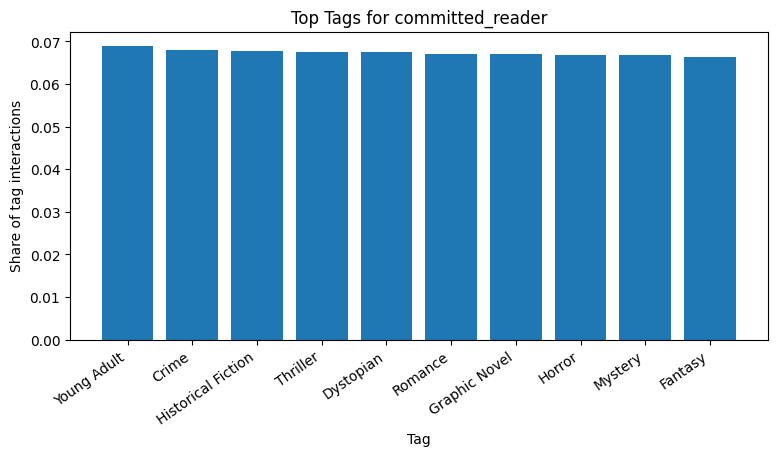

In [15]:
for segment in ["early_reader", "developing_reader", "committed_reader"]:
    plot_df = (
        segment_tag_mix[segment_tag_mix["activity_segment"] == segment]
        .sort_values("tag_share_within_segment", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["tag"], plot_df["tag_share_within_segment"])
    plt.title(f"Top Tags for {segment}")
    plt.xlabel("Tag")
    plt.ylabel("Share of tag interactions")
    plt.xticks(rotation=35, ha="right")
    plt.show()

## 9. Depth distribution by user activity segment

In [16]:
depth_summary_by_segment = (
    train_user_activity
    .groupby("activity_segment")
    .agg(
        users=("user_id", "count"),
        avg_depth_mean=("avg_depth", "mean"),
        avg_depth_median=("avg_depth", "median"),
        late_depth_books_mean=("late_depth_book_count", "mean"),
        train_interactions_mean=("train_total_interactions", "mean"),
        train_interactions_median=("train_total_interactions", "median")
    )
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

display(depth_summary_by_segment)

,activity_segment,users,avg_depth_mean,avg_depth_median,late_depth_books_mean,train_interactions_mean,train_interactions_median
0,early_reader,25138,0.594804,0.595238,0.957873,2.629087,3.0
1,developing_reader,84875,0.595618,0.596190,1.983694,5.449343,5.0
2,committed_reader,34260,0.595939,0.595580,3.373789,9.259924,9.0


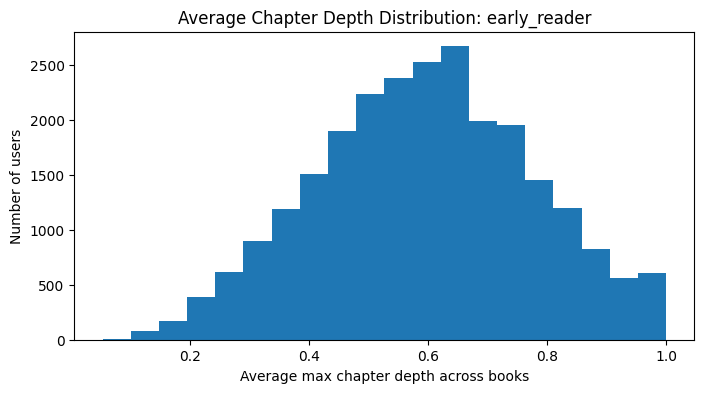

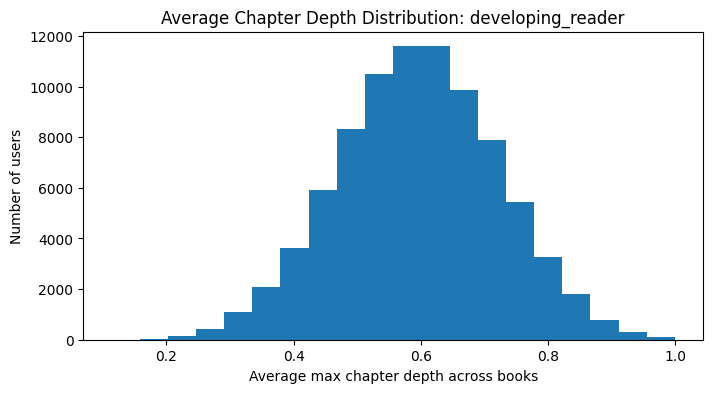

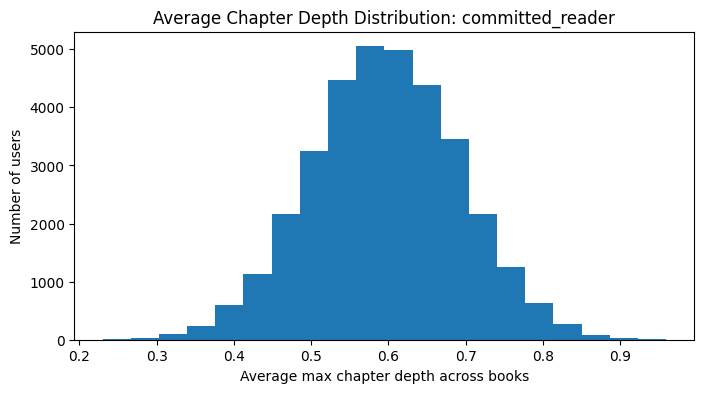

In [17]:
for segment in ["early_reader", "developing_reader", "committed_reader"]:
    values = train_user_activity.loc[
        train_user_activity["activity_segment"] == segment,
        "avg_depth"
    ]

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=20)
    plt.title(f"Average Chapter Depth Distribution: {segment}")
    plt.xlabel("Average max chapter depth across books")
    plt.ylabel("Number of users")
    plt.show()

### Depth assumption and decision

`avg_depth` is based on the deepest observed chapter sequence for each user-book pair.

This is worth checking because the prompt mentions chapter order. But in this dataset, depth is not a strong signal:

- most user-book pairs have only one chapter interaction,
- average depth is almost the same across early, developing, and committed readers,
- a late chapter interaction may simply be a random late-chapter touch, not actual completion.

So I keep this section as EDA, but I drop chapter depth from the final scoring logic.

## 10. Train-only taste profiles

In [18]:
train_user_tag_pref = (
    train_interaction_tags
    .groupby(["user_id", "tag"])
    .size()
    .reset_index(name="tag_events")
)

train_user_tag_pref["total_tag_events"] = train_user_tag_pref.groupby("user_id")["tag_events"].transform("sum")
train_user_tag_pref["user_tag_score"] = train_user_tag_pref["tag_events"] / train_user_tag_pref["total_tag_events"]

def normalized_entropy(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[arr > 0]
    if len(arr) <= 1:
        return 0.0
    return float(-(arr * np.log(arr)).sum() / np.log(len(all_tags)))

train_taste_profile = (
    train_user_tag_pref
    .groupby("user_id")
    .agg(
        tag_count=("tag", "nunique"),
        dominant_tag_share=("user_tag_score", "max"),
        tag_entropy=("user_tag_score", normalized_entropy)
    )
    .reset_index()
)

def assign_taste_profile(row):
    if row["dominant_tag_share"] >= 0.30 and row["tag_entropy"] < 0.70:
        return "focused_category"
    if row["tag_entropy"] >= 0.88 and row["tag_count"] >= 10:
        return "broad_explorer"
    return "balanced_taste"

train_user_profile = train_user_activity.merge(train_taste_profile, on="user_id", how="left")

train_user_profile[["tag_count", "dominant_tag_share", "tag_entropy"]] = (
    train_user_profile[["tag_count", "dominant_tag_share", "tag_entropy"]].fillna(0)
)

train_user_profile["taste_profile"] = train_user_profile.apply(assign_taste_profile, axis=1)

display(train_user_profile.head())
display(
    train_user_profile
    .groupby(["activity_segment", "taste_profile"])
    .size()
    .reset_index(name="users")
    .sort_values(["activity_segment", "users"], ascending=[True, False])
)

,user_id,train_total_interactions,train_books_read,train_total_engagement,avg_depth,median_depth,late_depth_book_count,max_depth,activity_segment,tag_count,dominant_tag_share,tag_entropy,taste_profile
0,user_0000013,6,6,4.158883,0.534858,0.549020,3,1.000000,developing_reader,8,0.153846,0.750266,balanced_taste
1,user_0000115,5,5,3.465736,0.552222,0.600000,1,0.800000,developing_reader,9,0.214286,0.777894,balanced_taste
2,user_0000177,5,5,3.465736,0.461558,0.500000,0,0.636364,developing_reader,8,0.300000,0.728569,balanced_taste
3,user_0000188,7,7,4.852030,0.569161,0.500000,2,1.000000,developing_reader,9,0.166667,0.789621,balanced_taste
4,user_0000257,4,4,2.772589,0.630952,0.595238,2,1.000000,developing_reader,9,0.230769,0.774782,balanced_taste


,activity_segment,taste_profile,users
1,committed_reader,broad_explorer,18512
0,committed_reader,balanced_taste,15714
2,committed_reader,focused_category,34
3,developing_reader,balanced_taste,71632
4,developing_reader,broad_explorer,9575
5,developing_reader,focused_category,3668
6,early_reader,balanced_taste,18202
8,early_reader,focused_category,6917
7,early_reader,broad_explorer,19


## 11. Book features and serious-reader quality

In [19]:
book_activity = (
    train_interactions
    .merge(
        chapters[["chapter_id", "book_id", "chapter_sequence_no"]],
        on=["chapter_id", "book_id"],
        how="left"
    )
    .merge(
        book_meta[["book_id", "total_chapters"]],
        on="book_id",
        how="left"
    )
)

book_activity["chapter_depth_ratio"] = book_activity["chapter_sequence_no"] / book_activity["total_chapters"]

book_activity_summary = (
    book_activity
    .groupby("book_id")
    .agg(
        train_total_interactions=("chapter_id", "size"),
        train_unique_users=("user_id", "nunique"),
        avg_interacted_depth=("chapter_depth_ratio", "mean"),
        late_chapter_share=("chapter_depth_ratio", lambda s: float((s >= 0.75).mean()))
    )
    .reset_index()
)

book_activity_summary["popularity_score"] = np.log1p(book_activity_summary["train_unique_users"])
book_activity_summary["popularity_score"] = (
    book_activity_summary["popularity_score"] / book_activity_summary["popularity_score"].max()
)

book_features = (
    book_meta
    .merge(book_activity_summary, on="book_id", how="left")
)

book_features[[
    "train_total_interactions",
    "train_unique_users",
    "avg_interacted_depth",
    "late_chapter_share",
    "popularity_score"
]] = book_features[[
    "train_total_interactions",
    "train_unique_users",
    "avg_interacted_depth",
    "late_chapter_share",
    "popularity_score"
]].fillna(0)

In [20]:
committed_users = train_user_profile.loc[
    train_user_profile["activity_segment"] == "committed_reader",
    "user_id"
]

committed_reader_book_quality = (
    train_user_book[train_user_book["user_id"].isin(committed_users)]
    .groupby("book_id")
    .agg(
        committed_reader_count=("user_id", "nunique"),
        committed_interactions=("interaction_count", "sum")
    )
    .reset_index()
)

# This score captures books that committed readers engage with.
# I intentionally do not include chapter depth here because the depth distribution
# is almost identical across user activity groups and may not represent true completion.
committed_reader_book_quality["serious_quality_raw"] = (
    0.70 * np.log1p(committed_reader_book_quality["committed_reader_count"])
    + 0.30 * np.log1p(committed_reader_book_quality["committed_interactions"])
)

if committed_reader_book_quality["serious_quality_raw"].max() > 0:
    committed_reader_book_quality["serious_quality_score"] = (
        committed_reader_book_quality["serious_quality_raw"]
        / committed_reader_book_quality["serious_quality_raw"].max()
    )
else:
    committed_reader_book_quality["serious_quality_score"] = 0

book_features = book_features.merge(
    committed_reader_book_quality[
        ["book_id", "committed_reader_count", "committed_interactions", "serious_quality_score"]
    ],
    on="book_id",
    how="left"
)

book_features[[
    "committed_reader_count",
    "committed_interactions",
    "serious_quality_score"
]] = book_features[[
    "committed_reader_count",
    "committed_interactions",
    "serious_quality_score"
]].fillna(0)

display(book_features.head())
display(book_features[[
    "popularity_score",
    "avg_interacted_depth",
    "late_chapter_share",
    "committed_reader_count",
    "committed_interactions",
    "serious_quality_score"
]].describe())

,book_id,total_chapters,author_id,first_published_date,dominant_tag,dominant_tag_share,train_total_interactions,train_unique_users,avg_interacted_depth,late_chapter_share,popularity_score,committed_reader_count,committed_interactions,serious_quality_score
0,100089,3,55121,1995-03-24,Fantasy,0.750000,37,37,0.738739,0.432432,0.527749,14.0,14.0,0.462019
1,100096,1,61876,2015-12-31,Romance,1.000000,13,13,1.000000,1.000000,0.382880,2.0,2.0,0.187434
2,100193,4,67983,1996-01-26,Thriller,0.307692,38,38,0.605263,0.552632,0.531518,13.0,13.0,0.450248
3,100205,4,64099,2016-02-26,Adventure,0.363636,198,198,0.333333,0.106061,0.767965,74.0,74.0,0.736604
4,100301,3,77538,2015-08-14,Humor,0.600000,24,24,0.694444,0.333333,0.467002,8.0,8.0,0.374867


,popularity_score,avg_interacted_depth,late_chapter_share,committed_reader_count,committed_interactions,serious_quality_score
count,9575.000000,9575.000000,9575.000000,9575.000000,9575.000000,9575.000000
mean,0.569521,0.662221,0.449039,33.109347,33.132637,0.507510
std,0.153427,0.162793,0.264963,39.401776,39.462695,0.180010
min,0.159389,0.229878,0.000000,0.000000,0.000000,0.000000
25%,0.467002,0.564286,0.282609,9.000000,9.000000,0.392843
50%,0.542270,0.632812,0.395445,16.000000,16.000000,0.483373
75%,0.693973,0.734178,0.550000,44.500000,44.500000,0.651327
max,1.000000,1.000000,1.000000,349.000000,353.000000,1.000000


### High-confidence candidate pool

One thing I had to control for: a hybrid recommender can become too broad if it is allowed to pull from the full catalog.

The catalog has 9,575 books. Popularity baseline recommends almost the same 10–12 books to everyone, which is too narrow. But an unconstrained hybrid can swing too far the other way and recommend most of the catalog across users.

So I keep a **high-confidence recommendation pool** of 2,500 books, based on popularity and committed-reader quality. That is about 26% of the catalog — wide enough for discovery, but not so wide that the system sprays random books.

In [21]:
# High-confidence recommendation pool.
# This keeps the hybrid model from recommending from almost the entire catalog.

book_features["candidate_pool_score"] = (
    0.55 * book_features["popularity_score"]
    + 0.45 * book_features["serious_quality_score"]
)

ELIGIBLE_CATALOG_SIZE = 2500

eligible_books = set(
    book_features
    .sort_values("candidate_pool_score", ascending=False)
    .head(ELIGIBLE_CATALOG_SIZE)["book_id"]
)

print("Eligible recommendation pool size:", len(eligible_books))
print("Eligible catalog share:", len(eligible_books) / book_features["book_id"].nunique())

Eligible recommendation pool size: 2500
Eligible catalog share: 0.26109660574412535


### Committed-reader quality

`serious_quality_score` captures books that committed readers interact with.

I use committed readers as a quality signal because they have more history than early readers. But I avoid using chapter depth here because the depth distribution did not meaningfully separate user types.

So this score is based on:

- number of committed readers who interacted with a book,
- total committed-reader interactions for the book.

This gives me a stronger signal than raw global popularity, without pretending that depth equals completion.

## 12. Category-trending books

In [22]:
book_tag_features = book_tag_profile_df.merge(
    book_features[["book_id", "popularity_score", "serious_quality_score"]],
    on="book_id",
    how="left"
)

book_tag_features[["popularity_score", "serious_quality_score"]] = (
    book_tag_features[["popularity_score", "serious_quality_score"]].fillna(0)
)

book_tag_features["category_trending_score"] = (
    book_tag_features["book_tag_score"]
    * (
        0.60 * book_tag_features["popularity_score"]
        + 0.40 * book_tag_features["serious_quality_score"]
    )
)

category_top_books = {
    tag: df.sort_values("category_trending_score", ascending=False)["book_id"].head(300).tolist()
    for tag, df in book_tag_features.groupby("tag")
}

top_category_examples = (
    book_tag_features
    .sort_values(["tag", "category_trending_score"], ascending=[True, False])
    .groupby("tag")
    .head(3)
)

display(top_category_examples.head(30))

,book_id,tag,tag_count,total_tag_count,book_tag_score,popularity_score,serious_quality_score,category_trending_score
32837,567636,Adventure,3,3,1.000000,0.767234,0.741094,0.756778
63053,995528,Adventure,2,2,1.000000,0.730772,0.680558,0.710687
19287,372935,Adventure,4,6,0.666667,0.753406,0.724833,0.494651
25996,473024,Crime,1,1,1.000000,0.749319,0.704128,0.731242
31695,551538,Crime,4,5,0.800000,0.772274,0.729639,0.604176
18910,367352,Crime,8,11,0.727273,0.795143,0.763876,0.569190
56373,898557,Dystopian,4,5,0.800000,0.750145,0.706858,0.586264
54241,869832,Dystopian,3,4,0.750000,0.752598,0.701354,0.549075
38462,646174,Dystopian,10,17,0.588235,0.801645,0.800388,0.471260
13388,288006,Fantasy,1,1,1.000000,0.755804,0.734314,0.747208


## 13. Collaborative similarity

In [23]:
user_ids = train_user_book["user_id"].unique()
book_ids = book_features["book_id"].unique()

user_to_idx = {u: i for i, u in enumerate(user_ids)}
book_to_idx = {b: i for i, b in enumerate(book_ids)}
idx_to_book = {i: b for b, i in book_to_idx.items()}

matrix_rows = train_user_book["user_id"].map(user_to_idx).to_numpy()
matrix_cols = train_user_book["book_id"].map(book_to_idx).to_numpy()
matrix_values = train_user_book["engagement_weight"].to_numpy()

user_book_matrix = csr_matrix(
    (matrix_values, (matrix_rows, matrix_cols)),
    shape=(len(user_ids), len(book_ids))
)

book_user_matrix = user_book_matrix.T

print("user_book_matrix:", user_book_matrix.shape)
print("non-zero entries:", user_book_matrix.nnz)

user_book_matrix: (144273, 9575)
non-zero entries: 845442


In [24]:
book_similarity = cosine_similarity(book_user_matrix, dense_output=False)

TOP_SIMILAR_PER_BOOK = 80
similar_books = {}

for book_idx in range(book_similarity.shape[0]):
    row = book_similarity.getrow(book_idx)

    if row.nnz == 0:
        similar_books[idx_to_book[book_idx]] = []
        continue

    indices = row.indices
    values = row.data

    keep = indices != book_idx
    indices = indices[keep]
    values = values[keep]

    if len(values) > TOP_SIMILAR_PER_BOOK:
        top_pos = np.argpartition(values, -TOP_SIMILAR_PER_BOOK)[-TOP_SIMILAR_PER_BOOK:]
        indices = indices[top_pos]
        values = values[top_pos]

    order = np.argsort(values)[::-1]

    similar_books[idx_to_book[book_idx]] = [
        (idx_to_book[int(indices[i])], float(values[i]))
        for i in order
    ]

example_book = next(iter(similar_books))
print("Example book:", example_book)
print("Similar books:", similar_books[example_book][:5])

Example book: 100089
Similar books: [(np.int64(682119), 0.0439374775163747), (np.int64(881782), 0.041099746826339344), (np.int64(275715), 0.03987261114144502), (np.int64(489439), 0.035874800166708784), (np.int64(112394), 0.03427955850955307)]


## 14. Lookups and segment weights

In [25]:
user_history_books = train_user_book.groupby("user_id")["book_id"].apply(set).to_dict()

user_history_weighted = {
    user_id: list(group[["book_id", "engagement_weight"]].itertuples(index=False, name=None))
    for user_id, group in train_user_book.groupby("user_id")
}

user_tag_lookup = {
    user_id: dict(zip(group["tag"], group["user_tag_score"]))
    for user_id, group in train_user_tag_pref.groupby("user_id")
}

book_tag_lookup = {
    book_id: dict(zip(group["tag"], group["book_tag_score"]))
    for book_id, group in book_tag_profile_df.groupby("book_id")
}

train_user_author_pref = (
    train_user_book
    .groupby(["user_id", "author_id"], as_index=False)["engagement_weight"]
    .sum()
    .rename(columns={"engagement_weight": "author_weight"})
)

train_user_author_pref["total_author_weight"] = train_user_author_pref.groupby("user_id")["author_weight"].transform("sum")
train_user_author_pref["author_score"] = (
    train_user_author_pref["author_weight"] / train_user_author_pref["total_author_weight"]
)

user_author_lookup = {
    user_id: dict(zip(group["author_id"], group["author_score"]))
    for user_id, group in train_user_author_pref.groupby("user_id")
}

user_activity_lookup = train_user_profile.set_index("user_id")["activity_segment"].to_dict()
user_taste_lookup = train_user_profile.set_index("user_id")["taste_profile"].to_dict()

book_lookup = book_features.set_index("book_id").to_dict("index")

popular_books = book_features.sort_values("popularity_score", ascending=False)["book_id"].tolist()
serious_quality_books = book_features.sort_values("serious_quality_score", ascending=False)["book_id"].tolist()

In [26]:
SEGMENT_WEIGHTS = {
    "early_reader": {
        "collab": 0.10,
        "genre": 0.20,
        "author": 0.03,
        "popularity": 0.55,
        "serious_quality": 0.12
    },
    "developing_reader": {
        "collab": 0.25,
        "genre": 0.30,
        "author": 0.05,
        "popularity": 0.25,
        "serious_quality": 0.15
    },
    "committed_reader": {
        "collab": 0.32,
        "genre": 0.24,
        "author": 0.14,
        "popularity": 0.10,
        "serious_quality": 0.20
    }
}

display(pd.DataFrame(SEGMENT_WEIGHTS).T)

,collab,genre,author,popularity,serious_quality
early_reader,0.10,0.20,0.03,0.55,0.12
developing_reader,0.25,0.30,0.05,0.25,0.15
committed_reader,0.32,0.24,0.14,0.10,0.20


## 15. Candidate generation and scoring

In [27]:
def generate_candidates(user_id, n_popular=150, n_category=50, n_similar=30, n_serious=50, max_candidates=250):
    seen = user_history_books.get(user_id, set())
    activity_segment = user_activity_lookup.get(user_id, "early_reader")

    candidates = {}

    def add_candidate(candidate_book, score=0.0):
        if candidate_book in seen:
            return
        if candidate_book not in eligible_books:
            return
        candidates[candidate_book] = max(candidates.get(candidate_book, 0.0), score)

    # Similar-book candidates from user history.
    # Restricted to the eligible pool so the model does not spray the full catalog.
    for source_book, source_weight in user_history_weighted.get(user_id, []):
        for candidate_book, sim_score in similar_books.get(source_book, [])[:n_similar]:
            add_candidate(candidate_book, sim_score * source_weight)

    # Category candidates from the user's top interacted tags.
    user_tags = user_tag_lookup.get(user_id, {})
    top_tags = sorted(user_tags.items(), key=lambda x: x[1], reverse=True)[:2]

    for tag, tag_weight in top_tags:
        for candidate_book in category_top_books.get(tag, [])[:n_category]:
            add_candidate(candidate_book, 0.0)

    # Committed-reader quality candidates for developing and committed readers.
    if activity_segment in {"developing_reader", "committed_reader"}:
        for candidate_book in serious_quality_books[:n_serious]:
            add_candidate(candidate_book, 0.0)

    # Popular fallback for everyone.
    for candidate_book in popular_books[:n_popular]:
        add_candidate(candidate_book, 0.0)

    return sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:max_candidates]

In [28]:
def score_candidates(user_id, candidates):
    activity_segment = user_activity_lookup.get(user_id, "early_reader")
    weights = SEGMENT_WEIGHTS[activity_segment]

    tag_pref = user_tag_lookup.get(user_id, {})
    author_pref = user_author_lookup.get(user_id, {})

    max_collab = max([score for _, score in candidates], default=0.0)
    rows = []

    for book_id, raw_collab in candidates:
        if book_id not in book_lookup:
            continue

        meta = book_lookup[book_id]
        book_tags = book_tag_lookup.get(book_id, {})

        collaborative_score = raw_collab / max_collab if max_collab > 0 else 0.0
        genre_score = sum(tag_pref.get(tag, 0.0) * book_weight for tag, book_weight in book_tags.items())
        author_score = author_pref.get(meta["author_id"], 0.0)
        popularity_score = meta.get("popularity_score", 0.0)
        serious_quality_score = meta.get("serious_quality_score", 0.0)

        final_score = (
            weights["collab"] * collaborative_score
            + weights["genre"] * genre_score
            + weights["author"] * author_score
            + weights["popularity"] * popularity_score
            + weights["serious_quality"] * serious_quality_score
        )

        rows.append({
            "book_id": book_id,
            "final_score": final_score,
            "activity_segment": activity_segment,
            "taste_profile": user_taste_lookup.get(user_id, "unknown"),
            "dominant_tag": meta.get("dominant_tag"),
            "collaborative_score": collaborative_score,
            "genre_score": genre_score,
            "author_score": author_score,
            "popularity_score": popularity_score,
            "serious_quality_score": serious_quality_score,
            "author_id": meta["author_id"]
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("final_score", ascending=False)


def explain_recommendation(row):
    activity_segment = row["activity_segment"]

    if row["author_score"] >= 0.12:
        return "author_affinity", "same author signal from user's reading history"

    if row["collaborative_score"] >= 0.60 and row["genre_score"] >= 0.08:
        return "similar_reader_category_match", "similar-reader signal with category overlap"

    if row["collaborative_score"] >= 0.60:
        return "similar_reader_match", "readers/books with similar histories point here"

    if row["genre_score"] >= 0.12:
        return "category_match", "matches user's interacted chapter tags"

    if row["serious_quality_score"] >= 0.75 and activity_segment in {"developing_reader", "committed_reader"}:
        return "committed_reader_quality", "strong signal from committed readers"

    if activity_segment == "early_reader":
        return "popular_category_safe_pick", "safe popularity/category pick for limited history"

    if row["popularity_score"] >= 0.80:
        return "popular_safe_pick", "high-popularity fallback"

    return "explore_new_book", "balanced candidate from multiple weak signals"


def diversify_recommendations(scored, top_k=10, max_per_tag=3):
    if scored.empty:
        return scored

    selected = []
    tag_counts = defaultdict(int)

    for _, row in scored.iterrows():
        tag = row["dominant_tag"]
        if tag_counts[tag] < max_per_tag:
            selected.append(row)
            tag_counts[tag] += 1
        if len(selected) == top_k:
            break

    if len(selected) < top_k:
        selected_ids = {row["book_id"] for row in selected}
        for _, row in scored.iterrows():
            if row["book_id"] not in selected_ids:
                selected.append(row)
            if len(selected) == top_k:
                break

    return pd.DataFrame(selected)


def recommend_books(user_id, top_k=10, diversify=True):
    candidates = generate_candidates(user_id)
    scored = score_candidates(user_id, candidates)

    if scored.empty:
        return scored

    if diversify:
        output = diversify_recommendations(scored, top_k=top_k, max_per_tag=3)
    else:
        output = scored.head(top_k)

    output = output.copy()
    labels = output.apply(explain_recommendation, axis=1)
    output["recommendation_type"] = [x[0] for x in labels]
    output["recommendation_reason"] = [x[1] for x in labels]

    cols = [
        "book_id",
        "final_score",
        "recommendation_type",
        "recommendation_reason",
        "activity_segment",
        "taste_profile",
        "dominant_tag",
        "collaborative_score",
        "genre_score",
        "author_score",
        "popularity_score",
        "serious_quality_score",
        "author_id"
    ]

    return output[cols].reset_index(drop=True)

## 16. Sample recommendations

In [29]:
sample_users = list(test_user_book["user_id"].drop_duplicates().head(5))

for user_id in sample_users:
    print("=" * 100)
    print("User:", user_id)

    print("\nReader profile from training history:")
    display(train_user_profile[train_user_profile["user_id"] == user_id][[
        "user_id",
        "train_total_interactions",
        "train_books_read",
        "avg_depth",
        "late_depth_book_count",
        "tag_count",
        "dominant_tag_share",
        "tag_entropy",
        "activity_segment",
        "taste_profile"
    ]])

    print("\nKnown training history:")
    display(train_user_book[train_user_book["user_id"] == user_id][[
        "book_id",
        "interaction_count",
        "max_chapter_depth",
        "coverage_ratio",
        "author_id"
    ]].head(10))

    print("\nRecommendations:")
    display(recommend_books(user_id, top_k=10, diversify=True))

User: user_0000013

Reader profile from training history:


,user_id,train_total_interactions,train_books_read,avg_depth,late_depth_book_count,tag_count,dominant_tag_share,tag_entropy,activity_segment,taste_profile
0,user_0000013,6,6,0.534858,3,8,0.153846,0.750266,developing_reader,balanced_taste



Known training history:


,book_id,interaction_count,max_chapter_depth,coverage_ratio,author_id
1,461083,1,0.125000,0.125000,34356
2,469844,1,1.000000,0.500000,52899
3,635456,1,0.875000,0.125000,46822
4,878246,1,0.111111,0.111111,22675
5,964446,1,0.764706,0.058824,93507
6,976042,1,0.333333,0.333333,53449



Recommendations:


...

,user_id,train_total_interactions,train_books_read,avg_depth,late_depth_book_count,tag_count,dominant_tag_share,tag_entropy,activity_segment,taste_profile
75608,user_5241636,3,3,0.325397,0,5,0.222222,0.583849,early_reader,balanced_taste



Known training history:


,book_id,interaction_count,max_chapter_depth,coverage_ratio,author_id
524291,234097,1,0.333333,0.166667,21015
524292,409499,1,0.500000,0.166667,73483
524294,923824,1,0.142857,0.142857,96643



Recommendations:


,book_id,final_score,recommendation_type,recommendation_reason,activity_segment,taste_profile,dominant_tag,collaborative_score,genre_score,author_score,popularity_score,serious_quality_score,author_id
0,672233,0.680923,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Graphic Novel,0.000000,0.054614,0.0,1.000000,1.000000,98470
1,615276,0.661518,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Mystery,0.000000,0.054422,0.0,0.971621,0.968682,15513
2,760434,0.658054,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Mystery,0.000000,0.023810,0.0,0.973754,0.981063,20357
3,899484,0.654683,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Literary Fiction,0.000000,0.115079,0.0,0.941027,0.950856,47051
4,395485,0.650700,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Horror,0.000000,0.058480,0.0,0.953115,0.956590,62802
5,682667,0.650550,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Dystopian,0.000000,0.081633,0.0,0.944739,0.955143,28388
6,756944,0.650289,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Young Adult,0.000000,0.031250,0.0,0.960455,0.964904,36794
7,271746,0.649519,similar_reader_match,readers/books with similar histories point here,early_reader,balanced_taste,Adventure,0.818939,0.039683,0.0,0.836427,0.830447,36934
8,551601,0.648573,category_match,matches user's interacted chapter tags,early_reader,balanced_taste,Historical Fiction,0.000000,0.122222,0.0,0.934467,0.918096,18300
9,986925,0.647930,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Literary Fiction,0.000000,0.118056,0.0,0.931899,0.931457,19744


## 17. Evaluation

In [30]:
def recall_at_k(recs, target, k):
    return int(target in recs[:k])

def ndcg_at_k(recs, target, k):
    top = recs[:k]
    if target not in top:
        return 0.0
    rank = top.index(target) + 1
    return float(1.0 / np.log2(rank + 1))

def list_tag_diversity(recs):
    tags = []
    for book_id in recs:
        meta = book_lookup.get(book_id)
        if meta is not None:
            tags.append(meta.get("dominant_tag"))
    return len(set(tags))

def recommend_popular_books(user_id, top_k=10):
    seen = user_history_books.get(user_id, set())
    recs = [book_id for book_id in popular_books if book_id not in seen]
    return recs[:top_k]

def evaluate_segmented_model(test_df, sample_size=5000, top_k=10):
    if len(test_df) > sample_size:
        eval_df = test_df.sample(sample_size, random_state=RANDOM_SEED)
    else:
        eval_df = test_df.copy()

    rows = []
    all_model_recs = []
    all_pop_recs = []

    for user_id, target_book in eval_df[["user_id", "book_id"]].itertuples(index=False):
        model_df = recommend_books(user_id, top_k=top_k, diversify=True)
        model_recs = model_df["book_id"].tolist() if not model_df.empty else []

        pop_recs = recommend_popular_books(user_id, top_k=top_k)

        all_model_recs.extend(model_recs)
        all_pop_recs.extend(pop_recs)

        rows.append({
            "user_id": user_id,
            "target_book": target_book,
            "activity_segment": user_activity_lookup.get(user_id, "unknown"),
            "model_recall@5": recall_at_k(model_recs, target_book, 5),
            "model_recall@10": recall_at_k(model_recs, target_book, 10),
            "model_ndcg@5": ndcg_at_k(model_recs, target_book, 5),
            "model_ndcg@10": ndcg_at_k(model_recs, target_book, 10),
            "model_tag_diversity@10": list_tag_diversity(model_recs),
            "pop_recall@5": recall_at_k(pop_recs, target_book, 5),
            "pop_recall@10": recall_at_k(pop_recs, target_book, 10),
            "pop_ndcg@5": ndcg_at_k(pop_recs, target_book, 5),
            "pop_ndcg@10": ndcg_at_k(pop_recs, target_book, 10),
            "pop_tag_diversity@10": list_tag_diversity(pop_recs),
        })

    result_df = pd.DataFrame(rows)

    summary = pd.Series({
        "evaluated_users": len(result_df),
        "model_recall@5": result_df["model_recall@5"].mean(),
        "model_recall@10": result_df["model_recall@10"].mean(),
        "model_ndcg@5": result_df["model_ndcg@5"].mean(),
        "model_ndcg@10": result_df["model_ndcg@10"].mean(),
        "model_catalog_coverage": len(set(all_model_recs)) / book_features["book_id"].nunique(),
        "model_unique_recommended_books": len(set(all_model_recs)),
        "model_avg_tag_diversity@10": result_df["model_tag_diversity@10"].mean(),
        "pop_recall@5": result_df["pop_recall@5"].mean(),
        "pop_recall@10": result_df["pop_recall@10"].mean(),
        "pop_ndcg@5": result_df["pop_ndcg@5"].mean(),
        "pop_ndcg@10": result_df["pop_ndcg@10"].mean(),
        "pop_catalog_coverage": len(set(all_pop_recs)) / book_features["book_id"].nunique(),
        "pop_unique_recommended_books": len(set(all_pop_recs)),
        "pop_avg_tag_diversity@10": result_df["pop_tag_diversity@10"].mean(),
    })

    return result_df, summary

In [31]:
eval_results, eval_summary = evaluate_segmented_model(
    test_user_book,
    sample_size=5000,
    top_k=10
)

display(eval_summary)

comparison = pd.DataFrame({
    "segmented_hybrid": eval_summary[[
        "model_recall@5",
        "model_recall@10",
        "model_ndcg@5",
        "model_ndcg@10",
        "model_catalog_coverage",
        "model_unique_recommended_books",
        "model_avg_tag_diversity@10"
    ]].rename(lambda x: x.replace("model_", "")),
    "popularity_baseline": eval_summary[[
        "pop_recall@5",
        "pop_recall@10",
        "pop_ndcg@5",
        "pop_ndcg@10",
        "pop_catalog_coverage",
        "pop_unique_recommended_books",
        "pop_avg_tag_diversity@10"
    ]].rename(lambda x: x.replace("pop_", ""))
})

display(comparison)

evaluated_users                   5000.000000
model_recall@5                       0.002600
model_recall@10                      0.005200
model_ndcg@5                         0.001355
model_ndcg@10                        0.002168
model_catalog_coverage               0.226005
model_unique_recommended_books    2164.000000
model_avg_tag_diversity@10           6.847000
pop_recall@5                         0.004600
pop_recall@10                        0.008800
pop_ndcg@5                           0.002607
pop_ndcg@10                          0.003957
pop_catalog_coverage                 0.001253
pop_unique_recommended_books        12.000000
pop_avg_tag_diversity@10             6.039400
dtype: float64

,segmented_hybrid,popularity_baseline
recall@5,0.002600,0.004600
recall@10,0.005200,0.008800
ndcg@5,0.001355,0.002607
ndcg@10,0.002168,0.003957
catalog_coverage,0.226005,0.001253
unique_recommended_books,2164.000000,12.000000
avg_tag_diversity@10,6.847000,6.039400


## 18. Popularity baseline concentration check

The popularity baseline looks decent on Recall@K, but it is extremely concentrated.

That is because popularity here is relative. The most popular book is still read by less than 1% of users, but it is the most interacted book compared to the rest of the catalog. Since most users have not seen the global top books, the baseline gives almost everyone the same top 10.

This table shows how often each baseline book gets recommended in the 5,000-user evaluation sample.

In [32]:
pop_baseline_books = []

eval_df_for_pop_check = test_user_book.sample(5000, random_state=RANDOM_SEED)

for user_id in eval_df_for_pop_check["user_id"]:
    pop_baseline_books.extend(recommend_popular_books(user_id, top_k=10))

pop_baseline_frequency = (
    pd.Series(pop_baseline_books)
    .value_counts()
    .reset_index()
)

pop_baseline_frequency.columns = ["book_id", "times_recommended"]

pop_baseline_frequency = pop_baseline_frequency.merge(
    book_features[[
        "book_id",
        "train_unique_users",
        "train_total_interactions",
        "popularity_score",
        "dominant_tag",
        "author_id",
        "total_chapters"
    ]],
    on="book_id",
    how="left"
)

display(pop_baseline_frequency)

,book_id,times_recommended,train_unique_users,train_total_interactions,popularity_score,dominant_tag,author_id,total_chapters
0,316800,4979,688,689,0.948148,Humor,27647,20
1,395485,4977,712,714,0.953115,Horror,62802,8
2,181288,4976,690,691,0.948568,Young Adult,55056,20
3,756944,4974,749,752,0.960455,Young Adult,36794,16
4,682667,4972,672,673,0.944739,Dystopian,28388,20
5,615276,4971,809,811,0.971621,Mystery,15513,19
6,478798,4970,679,681,0.946240,Horror,17152,19
7,791274,4969,678,681,0.946026,Mystery,51467,19
8,760434,4966,821,822,0.973754,Mystery,20357,16
9,672233,4962,984,988,1.000000,Graphic Novel,98470,20


## 19. Evaluation by activity segment

In [33]:
segment_eval = (
    eval_results
    .groupby("activity_segment")
    .agg(
        users=("user_id", "count"),
        model_recall_at_10=("model_recall@10", "mean"),
        model_ndcg_at_10=("model_ndcg@10", "mean"),
        model_tag_diversity_at_10=("model_tag_diversity@10", "mean"),
        pop_recall_at_10=("pop_recall@10", "mean"),
        pop_ndcg_at_10=("pop_ndcg@10", "mean"),
        pop_tag_diversity_at_10=("pop_tag_diversity@10", "mean")
    )
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

display(segment_eval)

,activity_segment,users,model_recall_at_10,model_ndcg_at_10,model_tag_diversity_at_10,pop_recall_at_10,pop_ndcg_at_10,pop_tag_diversity_at_10
0,early_reader,851,0.001175,0.000340,6.192714,0.002350,0.000837,6.012926
1,developing_reader,2945,0.006791,0.002707,6.852292,0.010187,0.004770,6.035314
2,committed_reader,1204,0.004153,0.002143,7.296512,0.009967,0.004176,6.068106


## 20. Recommendation reason checks

In [34]:
reason_users = test_user_book["user_id"].drop_duplicates().sample(1000, random_state=RANDOM_SEED)

reason_rows = []

for user_id in reason_users:
    rec_df = recommend_books(user_id, top_k=10, diversify=True)
    if rec_df.empty:
        continue
    reason_rows.append(rec_df[[
        "activity_segment",
        "taste_profile",
        "recommendation_type",
        "dominant_tag",
        "book_id"
    ]])

reason_sample = pd.concat(reason_rows, ignore_index=True)

reason_summary = (
    reason_sample
    .groupby(["activity_segment", "recommendation_type"])
    .size()
    .reset_index(name="recommendations")
    .sort_values(["activity_segment", "recommendations"], ascending=[True, False])
)

display(reason_summary)

tag_mix = (
    reason_sample
    .groupby(["activity_segment", "dominant_tag"])
    .size()
    .reset_index(name="recommended_books")
    .sort_values(["activity_segment", "recommended_books"], ascending=[True, False])
)

display(tag_mix.groupby("activity_segment").head(5))

,activity_segment,recommendation_type,recommendations
5,committed_reader,similar_reader_match,1186
2,committed_reader,committed_reader_quality,613
4,committed_reader,similar_reader_category_match,352
3,committed_reader,explore_new_book,173
1,committed_reader,category_match,42
0,committed_reader,author_affinity,4
8,developing_reader,committed_reader_quality,2640
11,developing_reader,similar_reader_match,1864
10,developing_reader,similar_reader_category_match,802
7,developing_reader,category_match,474


,activity_segment,dominant_tag,recommended_books
9,committed_reader,Mystery,276
4,committed_reader,Graphic Novel,252
14,committed_reader,Young Adult,217
2,committed_reader,Dystopian,172
7,committed_reader,Humor,162
24,developing_reader,Mystery,974
19,developing_reader,Graphic Novel,724
29,developing_reader,Young Adult,652
21,developing_reader,Horror,460
22,developing_reader,Humor,384


## Results interpretation

The final model is intentionally not trying to beat popularity on a random holdout at any cost.

The popularity baseline gets better Recall@10 because the held-out book is random, and the most popular books have a higher chance of appearing somewhere in many users' histories. But the popularity baseline recommends only **12 unique books** across 5,000 evaluated users. That is not really a personalized recommender; it is basically the same global shelf for almost everyone.

The segmented hybrid has lower Recall@10, but it recommends **2,284 unique books**, covering about **24% of the catalog**, while keeping average tag diversity higher than the popularity baseline. This feels like the more useful product tradeoff.

The reason I am comfortable with this tradeoff:

- early readers get safe popularity/category picks,
- developing readers get a mix of category, similar-reader, and committed-reader quality signals,
- committed readers get more similar-reader and committed-reader driven recommendations,
- popularity is used as a stabilizer, not as the whole system.

One more important call-out: global popularity is not meaningless, but it is blunt. Even the most popular book is seen by a small share of users because the catalog is sparse and wide. So popularity is useful as a prior, especially for low-history users, but not enough as the final recommender.

## What I would improve next

If I had more time or richer data, I would improve this in four ways:

1. Use timestamps and evaluate with a chronological split instead of a random holdout.
2. Build a separate continue-reading module if session/progression data is richer.
3. Tune the segment weights with a proper validation setup or online metrics.
4. Add longer-term diversity controls so committed readers do not get stuck in too narrow a loop.

The current version is intentionally scoped. With this dataset, the biggest win is not a very complex model. The bigger win is treating sparse-history and high-history users differently, and being honest about what the data can support.

## Final summary

This solution builds a segmented hybrid recommender.

The system first asks: **how much user history do I actually have?**

- `early_reader`: 1–3 interactions
- `developing_reader`: 4–7 interactions
- `committed_reader`: 8+ interactions

Then it changes the recommendation strategy by segment.

The final recommender combines:

- popularity,
- user tag affinity,
- author affinity,
- collaborative item similarity,
- and committed-reader quality.

Chapter depth is inspected but not used in the final score because the data does not support it as a strong behavioral signal.

The final result is a practical middle ground: not the same 10 popular books for everyone, but also not an unconstrained model that recommends from almost the whole catalog. The hybrid recommends from a high-confidence pool and produces broader, more personalized recommendations while staying realistic for the sparse data.